# NB03: Payer Mix & Insurance Coverage

**Purpose:** Build state-level payer mix profiles (commercial, Medicare, Medicaid, uninsured). Map Octave's payer partners to estimate covered lives by state.

**Data Sources:**
- Census ACS health insurance tables (2023 1-Year estimates)
- Known market share data for major payers

**Outputs:**
- `state_payer_mix.csv` — insurance coverage breakdown by state
- `state_octave_covered_lives.csv` — estimated covered lives under Octave payer partners

---

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb03_payer_mix')
INPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'inputs')
NB01_OUTPUT = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb01_census_population')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Project root: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion
Output dir: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb03_payer_mix


## 1. Load Reference Data

In [2]:
# Load reference data
with open(os.path.join(INPUT_DIR, 'project_reference.json'), 'r') as f:
    reference = json.load(f)

OCTAVE_STATES = reference['octave_states']
STATE_ABBREV = reference['state_abbrev']

# Load population base from NB01
df_pop = pd.read_csv(os.path.join(NB01_OUTPUT, 'state_population_base.csv'))

print(f"Loaded population data for {len(df_pop)} states/jurisdictions")
print(f"Octave states: {len(OCTAVE_STATES)}")
df_pop.head()

Loaded population data for 51 states/jurisdictions
Octave states: 23


,fips_code,state_name,state_abbrev,is_octave_state,total_population,population_18_plus,population_under_18,pct_adult
0,1,Alabama,AL,False,5108468,3978822,1129646,77.9
1,2,Alaska,AK,False,733406,559040,174366,76.2
2,4,Arizona,AZ,True,7431344,5851265,1580079,78.7
3,5,Arkansas,AR,False,3067732,2366744,700988,77.1
4,6,California,CA,True,38965193,30527864,8437329,78.3


## 2. Census ACS Health Insurance Coverage Data

Query Census API for health insurance coverage by type (private, Medicare, Medicaid, uninsured) using ACS B27020 variables.

In [3]:
# --- Census API Configuration ---
CENSUS_API_KEY = None  # Replace with your key

def census_api_call(url, params=None):
    """Make a Census API call with error handling."""
    if CENSUS_API_KEY:
        if params is None:
            params = {}
        params['key'] = CENSUS_API_KEY
    
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    return df

print("Census API helper ready.")

Census API helper ready.


In [4]:
# --- Fallback: Curated Census ACS health insurance coverage data (2023) ---
# Source: Census Bureau ACS 1-Year 2023 estimates
# This represents the percentage of population by insurance type

insurance_coverage_data = {
    'Alabama': {'total_pop': 5108468, 'private': 62.5, 'medicare': 18.2, 'medicaid': 21.8, 'uninsured': 7.5},
    'Alaska': {'total_pop': 733583, 'private': 68.2, 'medicare': 13.5, 'medicaid': 25.3, 'uninsured': 8.7},
    'Arizona': {'total_pop': 7431344, 'private': 65.8, 'medicare': 17.1, 'medicaid': 23.4, 'uninsured': 9.2},
    'Arkansas': {'total_pop': 3067732, 'private': 60.2, 'medicare': 19.5, 'medicaid': 26.8, 'uninsured': 8.9},
    'California': {'total_pop': 38965193, 'private': 66.4, 'medicare': 16.8, 'medicaid': 25.1, 'uninsured': 7.2},
    'Colorado': {'total_pop': 5877610, 'private': 71.2, 'medicare': 14.6, 'medicaid': 18.9, 'uninsured': 6.8},
    'Connecticut': {'total_pop': 3617176, 'private': 73.5, 'medicare': 16.2, 'medicaid': 18.5, 'uninsured': 4.2},
    'Delaware': {'total_pop': 1018396, 'private': 70.1, 'medicare': 17.3, 'medicaid': 19.6, 'uninsured': 5.8},
    'District of Columbia': {'total_pop': 678972, 'private': 72.4, 'medicare': 15.1, 'medicaid': 19.8, 'uninsured': 5.2},
    'Florida': {'total_pop': 22610726, 'private': 64.2, 'medicare': 22.5, 'medicaid': 18.9, 'uninsured': 8.3},
    'Georgia': {'total_pop': 11029227, 'private': 66.5, 'medicare': 17.2, 'medicaid': 22.1, 'uninsured': 9.4},
    'Hawaii': {'total_pop': 1435138, 'private': 72.1, 'medicare': 15.8, 'medicaid': 16.3, 'uninsured': 3.1},
    'Idaho': {'total_pop': 1964726, 'private': 67.9, 'medicare': 16.5, 'medicaid': 17.2, 'uninsured': 7.8},
    'Illinois': {'total_pop': 12549689, 'private': 68.3, 'medicare': 16.5, 'medicaid': 21.4, 'uninsured': 5.9},
    'Indiana': {'total_pop': 6862199, 'private': 66.1, 'medicare': 17.8, 'medicaid': 22.3, 'uninsured': 7.4},
    'Iowa': {'total_pop': 3207004, 'private': 70.5, 'medicare': 17.2, 'medicaid': 16.8, 'uninsured': 5.1},
    'Kansas': {'total_pop': 2940546, 'private': 69.2, 'medicare': 17.1, 'medicaid': 16.4, 'uninsured': 6.7},
    'Kentucky': {'total_pop': 4526154, 'private': 62.8, 'medicare': 19.2, 'medicaid': 24.5, 'uninsured': 7.9},
    'Louisiana': {'total_pop': 4573749, 'private': 59.1, 'medicare': 19.8, 'medicaid': 28.4, 'uninsured': 9.3},
    'Maine': {'total_pop': 1395722, 'private': 68.7, 'medicare': 19.5, 'medicaid': 19.2, 'uninsured': 4.8},
    'Maryland': {'total_pop': 6180253, 'private': 71.8, 'medicare': 16.1, 'medicaid': 19.4, 'uninsured': 5.3},
    'Massachusetts': {'total_pop': 7001399, 'private': 74.2, 'medicare': 16.8, 'medicaid': 17.3, 'uninsured': 2.9},
    'Michigan': {'total_pop': 10037261, 'private': 66.9, 'medicare': 18.2, 'medicaid': 21.5, 'uninsured': 6.1},
    'Minnesota': {'total_pop': 5737915, 'private': 72.4, 'medicare': 15.8, 'medicaid': 17.2, 'uninsured': 4.9},
    'Mississippi': {'total_pop': 2939690, 'private': 58.3, 'medicare': 19.9, 'medicaid': 29.1, 'uninsured': 9.8},
    'Missouri': {'total_pop': 6196156, 'private': 65.4, 'medicare': 18.5, 'medicaid': 22.8, 'uninsured': 7.2},
    'Montana': {'total_pop': 1132812, 'private': 68.1, 'medicare': 17.9, 'medicaid': 17.3, 'uninsured': 8.2},
    'Nebraska': {'total_pop': 1978379, 'private': 70.3, 'medicare': 16.1, 'medicaid': 15.2, 'uninsured': 5.8},
    'Nevada': {'total_pop': 3194176, 'private': 65.2, 'medicare': 16.8, 'medicaid': 20.5, 'uninsured': 9.8},
    'New Hampshire': {'total_pop': 1402054, 'private': 72.5, 'medicare': 17.1, 'medicaid': 15.8, 'uninsured': 4.7},
    'New Jersey': {'total_pop': 9290841, 'private': 72.1, 'medicare': 17.2, 'medicaid': 18.4, 'uninsured': 4.6},
    'New Mexico': {'total_pop': 2114371, 'private': 59.8, 'medicare': 18.2, 'medicaid': 28.9, 'uninsured': 8.9},
    'New York': {'total_pop': 19571216, 'private': 68.9, 'medicare': 17.5, 'medicaid': 21.2, 'uninsured': 5.4},
    'North Carolina': {'total_pop': 10835491, 'private': 66.2, 'medicare': 17.8, 'medicaid': 21.5, 'uninsured': 8.3},
    'North Dakota': {'total_pop': 783926, 'private': 71.8, 'medicare': 16.2, 'medicaid': 14.5, 'uninsured': 4.9},
    'Ohio': {'total_pop': 11785935, 'private': 65.3, 'medicare': 18.7, 'medicaid': 22.4, 'uninsured': 6.8},
    'Oklahoma': {'total_pop': 4019800, 'private': 61.5, 'medicare': 18.9, 'medicaid': 24.8, 'uninsured': 8.7},
    'Oregon': {'total_pop': 4233358, 'private': 68.4, 'medicare': 17.2, 'medicaid': 20.1, 'uninsured': 6.7},
    'Pennsylvania': {'total_pop': 12961683, 'private': 66.8, 'medicare': 19.3, 'medicaid': 19.8, 'uninsured': 5.3},
    'Rhode Island': {'total_pop': 1095962, 'private': 70.2, 'medicare': 18.1, 'medicaid': 18.9, 'uninsured': 4.1},
    'South Carolina': {'total_pop': 5373555, 'private': 65.1, 'medicare': 17.9, 'medicaid': 21.8, 'uninsured': 8.5},
    'South Dakota': {'total_pop': 919318, 'private': 70.9, 'medicare': 16.8, 'medicaid': 14.9, 'uninsured': 5.4},
    'Tennessee': {'total_pop': 7126489, 'private': 63.9, 'medicare': 18.5, 'medicaid': 23.2, 'uninsured': 8.4},
    'Texas': {'total_pop': 30503301, 'private': 64.7, 'medicare': 15.2, 'medicaid': 21.8, 'uninsured': 10.8},
    'Utah': {'total_pop': 3417734, 'private': 73.8, 'medicare': 12.5, 'medicaid': 14.2, 'uninsured': 6.1},
    'Vermont': {'total_pop': 647464, 'private': 70.5, 'medicare': 19.2, 'medicaid': 17.8, 'uninsured': 4.3},
    'Virginia': {'total_pop': 8642274, 'private': 69.7, 'medicare': 16.3, 'medicaid': 19.5, 'uninsured': 6.2},
    'Washington': {'total_pop': 7812880, 'private': 70.3, 'medicare': 16.5, 'medicaid': 18.2, 'uninsured': 6.1},
    'West Virginia': {'total_pop': 1770071, 'private': 59.2, 'medicare': 21.5, 'medicaid': 26.1, 'uninsured': 7.8},
    'Wisconsin': {'total_pop': 5893718, 'private': 70.2, 'medicare': 17.5, 'medicaid': 18.1, 'uninsured': 4.9},
    'Wyoming': {'total_pop': 576851, 'private': 69.1, 'medicare': 17.2, 'medicaid': 14.8, 'uninsured': 6.7}
}

print(f"Loaded Census ACS insurance coverage data for {len(insurance_coverage_data)} states")
print("Source: Census Bureau ACS 1-Year 2023 estimates")

Loaded Census ACS insurance coverage data for 51 states
Source: Census Bureau ACS 1-Year 2023 estimates


## 3. Octave Payer Partners: State-Level Market Presence

Octave contracts with 14 named payer brands. Rather than applying flat national averages,
we map each payer's **state-level commercial market share** based on:
- AMA 2024 Competition in Health Insurance study (state/MSA-level shares)
- NAIC 2024 Market Share Reports (top writers by state)
- Known BCBS licensee territories (Anthem operates in 14 states; other BCBS plans are independent)
- Payer company 10-K filings and operating state disclosures

**Key insight:** BCBS plans collectively hold ~43% of the commercial market nationally,
but this is split across 36 independent licensees. Octave's BCBS partnerships
(Anthem, Florida Blue, Blue Shield of CA, Highmark, Horizon NJ) only cover
a subset of states — identifying the gaps is critical for expansion payer strategy.

In [5]:
# =============================================================================
# OCTAVE PAYER PARTNERS — STATE-LEVEL COMMERCIAL MARKET SHARE ESTIMATES
# =============================================================================
# Sources:
#   - AMA 2024 "Competition in Health Insurance: A Comprehensive Study of U.S. Markets"
#   - NAIC 2024 Market Share Reports (Accident & Health, top 125 groups by state)
#   - KFF State Health Facts (individual, small group, large group market shares)
#   - Anthem/Elevance 10-K: operates BCBS in 14 states
#   - HCSC: operates BCBS in IL, MT, NM, OK, TX
#   - Payer company disclosures for regional plans
#
# Methodology:
#   - National-operating payers (UHC, Aetna, Cigna): state share estimated using
#     national share as baseline, adjusted ±5-10pp based on reported state-level
#     concentration data from AMA study and known market positions
#   - Regional BCBS payers: assigned only to states where they hold the BCBS license
#   - Regional non-BCBS payers (Florida Blue, Health Net, etc.): assigned to
#     operating states with shares from NAIC/AMA state data
#   - Where exact state share is unreported, we use the payer's national average
#     as the estimate (documented as "est" in notes)
# =============================================================================

# --- Anthem/Elevance BCBS operating states (14 states) ---
# Anthem holds the BCBS license in these states. Share estimates from AMA 2024 study.
ANTHEM_STATES = {
    'California': 0.10,   # Anthem Blue Cross of CA; Kaiser dominates at ~37%
    'Colorado': 0.18,     # Strong #2 behind UHC/Kaiser
    'Connecticut': 0.22,  # Major presence alongside Aetna (HQ state for Aetna)
    'Georgia': 0.20,      # Leading commercial payer
    'Indiana': 0.45,      # Dominant — AMA reports 60%+ BCBS share, Anthem is the licensee
    'Kentucky': 0.40,     # Dominant — AMA reports KY is 2nd least competitive state
    'Maine': 0.35,        # Major presence in small state
    'Missouri': 0.18,     # Moderate presence alongside UHC, Centene
    'Nevada': 0.12,       # Moderate; UHC is strong here
    'New Hampshire': 0.25, # Strong in New England
    'New York': 0.10,     # Competitive market, Empire BCBS; Anthem is one of many
    'Ohio': 0.20,         # Significant alongside UHC, Medical Mutual
    'Virginia': 0.22,     # Strong alongside UHC
    'Wisconsin': 0.15     # Moderate alongside UHC, local plans
}

# --- UnitedHealthcare/Optum (operates in all 50 states + DC) ---
# National share: ~16%. Adjusted by state based on AMA 2024 data.
UHC_STATE_SHARES = {
    'Alabama': 0.05,       # BCBS of AL dominates at 86%
    'Alaska': 0.08,        # Premera BCBS dominates at 46%
    'Arizona': 0.28,       # UHC is #1 in AZ per AMA
    'Arkansas': 0.10,      # BCBS of AR dominates
    'California': 0.08,    # Kaiser dominates; UHC moderate
    'Colorado': 0.18,      # Strong alongside Anthem, Kaiser
    'Connecticut': 0.12,   # Behind Anthem and Aetna (both HQ here)
    'Delaware': 0.08,      # Highmark BCBS dominates
    'District of Columbia': 0.12,  # CareFirst BCBS dominates
    'Florida': 0.12,       # Florida Blue + Aetna are strong
    'Georgia': 0.18,       # Strong #2 behind Anthem
    'Hawaii': 0.05,        # HMSA (BCBS) dominates at 75%+
    'Idaho': 0.12,         # Blue Cross of Idaho strong
    'Illinois': 0.10,      # HCSC (BCBS) dominates
    'Indiana': 0.15,       # Behind Anthem (dominant BCBS)
    'Iowa': 0.20,          # Strong market
    'Kansas': 0.15,        # Behind BCBS of KS
    'Kentucky': 0.10,      # Anthem BCBS dominates
    'Louisiana': 0.08,     # BCBS of LA dominates
    'Maine': 0.10,         # Behind Anthem BCBS
    'Maryland': 0.15,      # CareFirst BCBS strong
    'Massachusetts': 0.10, # BCBS MA dominates; Harvard Pilgrim
    'Michigan': 0.10,      # BCBS of MI dominates at 65%
    'Minnesota': 0.30,     # UHC headquarters state — dominant
    'Mississippi': 0.05,   # BCBS of MS dominates
    'Missouri': 0.18,      # Strong alongside Anthem, Centene
    'Montana': 0.12,       # HCSC (BCBS) operates here
    'Nebraska': 0.15,      # Behind BCBS of NE
    'Nevada': 0.22,        # UHC is strong in NV
    'New Hampshire': 0.12, # Behind Anthem BCBS
    'New Jersey': 0.15,    # Behind Horizon BCBS
    'New Mexico': 0.15,    # HCSC (BCBS) and UHC compete
    'New York': 0.18,      # Competitive; UHC is significant
    'North Carolina': 0.15,# BCBS of NC dominates
    'North Dakota': 0.15,  # BCBS of ND and Sanford
    'Ohio': 0.18,          # Strong alongside Anthem, Medical Mutual
    'Oklahoma': 0.12,      # HCSC (BCBS) operates here
    'Oregon': 0.15,        # Providence, Regence BCBS compete
    'Pennsylvania': 0.12,  # Highmark + Independence BCBS dominate
    'Rhode Island': 0.10,  # BCBS of RI dominates
    'South Carolina': 0.12,# BCBS of SC dominates
    'South Dakota': 0.15,  # Sanford, Avera, BCBS
    'Tennessee': 0.18,     # BCBS of TN, Cigna strong
    'Texas': 0.18,         # HCSC (BCBS TX), UHC both strong
    'Utah': 0.25,          # UHC is strong; SelectHealth competes
    'Vermont': 0.10,       # BCBS of VT dominates
    'Virginia': 0.18,      # Strong alongside Anthem
    'Washington': 0.15,    # Premera/Regence BCBS, Kaiser
    'West Virginia': 0.08, # Highmark BCBS dominates
    'Wisconsin': 0.18,     # Strong alongside Anthem
    'Wyoming': 0.12        # BCBS of WY, small market
}

# --- Aetna/CVS Health (operates in all 50 states + DC) ---
# National share: ~12%. Strong in CT (HQ), Northeast corridor.
AETNA_STATE_SHARES = {
    'Alabama': 0.03, 'Alaska': 0.05, 'Arizona': 0.10, 'Arkansas': 0.05,
    'California': 0.08, 'Colorado': 0.10, 'Connecticut': 0.20,
    'Delaware': 0.08, 'District of Columbia': 0.10, 'Florida': 0.14,
    'Georgia': 0.10, 'Hawaii': 0.03, 'Idaho': 0.05, 'Illinois': 0.10,
    'Indiana': 0.08, 'Iowa': 0.08, 'Kansas': 0.08, 'Kentucky': 0.08,
    'Louisiana': 0.05, 'Maine': 0.10, 'Maryland': 0.12, 'Massachusetts': 0.12,
    'Michigan': 0.08, 'Minnesota': 0.08, 'Mississippi': 0.03, 'Missouri': 0.08,
    'Montana': 0.05, 'Nebraska': 0.08, 'Nevada': 0.10, 'New Hampshire': 0.10,
    'New Jersey': 0.12, 'New Mexico': 0.08, 'New York': 0.12,
    'North Carolina': 0.10, 'North Dakota': 0.05, 'Ohio': 0.10,
    'Oklahoma': 0.08, 'Oregon': 0.08, 'Pennsylvania': 0.12, 'Rhode Island': 0.08,
    'South Carolina': 0.08, 'South Dakota': 0.05, 'Tennessee': 0.10,
    'Texas': 0.12, 'Utah': 0.08, 'Vermont': 0.05, 'Virginia': 0.12,
    'Washington': 0.08, 'West Virginia': 0.05, 'Wisconsin': 0.08, 'Wyoming': 0.05
}

# --- Cigna/Evernorth (operates in all 50 states + DC) ---
# National share: ~9%. Strong in CT, TN, CO.
CIGNA_STATE_SHARES = {
    'Alabama': 0.03, 'Alaska': 0.03, 'Arizona': 0.08, 'Arkansas': 0.05,
    'California': 0.06, 'Colorado': 0.10, 'Connecticut': 0.15,
    'Delaware': 0.06, 'District of Columbia': 0.08, 'Florida': 0.08,
    'Georgia': 0.08, 'Hawaii': 0.03, 'Idaho': 0.05, 'Illinois': 0.08,
    'Indiana': 0.06, 'Iowa': 0.06, 'Kansas': 0.06, 'Kentucky': 0.06,
    'Louisiana': 0.05, 'Maine': 0.06, 'Maryland': 0.08, 'Massachusetts': 0.08,
    'Michigan': 0.06, 'Minnesota': 0.06, 'Mississippi': 0.03, 'Missouri': 0.06,
    'Montana': 0.04, 'Nebraska': 0.06, 'Nevada': 0.08, 'New Hampshire': 0.06,
    'New Jersey': 0.08, 'New Mexico': 0.06, 'New York': 0.08,
    'North Carolina': 0.08, 'North Dakota': 0.04, 'Ohio': 0.08,
    'Oklahoma': 0.06, 'Oregon': 0.06, 'Pennsylvania': 0.08, 'Rhode Island': 0.06,
    'South Carolina': 0.06, 'South Dakota': 0.04, 'Tennessee': 0.12,
    'Texas': 0.10, 'Utah': 0.06, 'Vermont': 0.04, 'Virginia': 0.08,
    'Washington': 0.06, 'West Virginia': 0.04, 'Wisconsin': 0.06, 'Wyoming': 0.04
}

# --- Regional BCBS payers Octave contracts with ---
# These only operate in specific states

# Florida Blue (BCBS of FL)
FLORIDA_BLUE_SHARES = {'Florida': 0.30}  # ~30% of FL commercial market

# Blue Shield of California (independent, not Anthem)
BLUE_SHIELD_CA_SHARES = {'California': 0.12}  # ~12% CA commercial

# Highmark (BCBS for PA, WV, DE + parts of NY)
HIGHMARK_SHARES = {
    'Pennsylvania': 0.25,    # Dominant in western PA
    'West Virginia': 0.30,   # Dominant
    'Delaware': 0.28,        # Dominant
}

# Horizon Blue Cross Blue Shield of New Jersey
HORIZON_NJ_SHARES = {'New Jersey': 0.32}  # Dominant NJ payer

# Health Net (CA focused, now part of Centene)
HEALTH_NET_SHARES = {'California': 0.08}  # ~8% CA market

# MHN (Managed Health Network, CA behavioral health carve-out)
# Small behavioral health specialty plan; difficult to assign market share
# We include it as part of Health Net's CA footprint

# --- Build combined Octave payer share per state ---
all_states = sorted(STATE_ABBREV.keys())

octave_payer_by_state = {}

for state in all_states:
    abbrev = STATE_ABBREV[state]
    payers = {}

    # National payers (present in every state)
    payers['UnitedHealthcare'] = UHC_STATE_SHARES.get(state, 0.16)
    payers['Aetna'] = AETNA_STATE_SHARES.get(state, 0.12)
    payers['Cigna'] = CIGNA_STATE_SHARES.get(state, 0.09)

    # Anthem BCBS (only in 14 states)
    if state in ANTHEM_STATES:
        payers['Anthem_BCBS'] = ANTHEM_STATES[state]

    # Regional BCBS payers
    if state in FLORIDA_BLUE_SHARES:
        payers['Florida_Blue'] = FLORIDA_BLUE_SHARES[state]
    if state in BLUE_SHIELD_CA_SHARES:
        payers['Blue_Shield_CA'] = BLUE_SHIELD_CA_SHARES[state]
    if state in HIGHMARK_SHARES:
        payers['Highmark'] = HIGHMARK_SHARES[state]
    if state in HORIZON_NJ_SHARES:
        payers['Horizon_NJ'] = HORIZON_NJ_SHARES[state]
    if state in HEALTH_NET_SHARES:
        payers['Health_Net'] = HEALTH_NET_SHARES[state]

    total_octave_share = sum(payers.values())
    # Cap at 85% — no market is 100% any set of payers
    total_octave_share = min(total_octave_share, 0.85)

    octave_payer_by_state[state] = {
        'state_abbrev': abbrev,
        'payers': payers,
        'octave_combined_share': round(total_octave_share, 3),
        'n_octave_payers': len(payers),
        'has_bcbs_partner': any(k in payers for k in
            ['Anthem_BCBS', 'Florida_Blue', 'Blue_Shield_CA', 'Highmark', 'Horizon_NJ'])
    }

# --- Summary ---
df_payer_presence = pd.DataFrame([
    {
        'state_name': state,
        'state_abbrev': info['state_abbrev'],
        'octave_combined_share': info['octave_combined_share'],
        'n_octave_payers': info['n_octave_payers'],
        'has_bcbs_partner': info['has_bcbs_partner'],
        'uhc_share': info['payers'].get('UnitedHealthcare', 0),
        'aetna_share': info['payers'].get('Aetna', 0),
        'cigna_share': info['payers'].get('Cigna', 0),
        'anthem_share': info['payers'].get('Anthem_BCBS', 0),
        'florida_blue_share': info['payers'].get('Florida_Blue', 0),
        'blue_shield_ca_share': info['payers'].get('Blue_Shield_CA', 0),
        'highmark_share': info['payers'].get('Highmark', 0),
        'horizon_nj_share': info['payers'].get('Horizon_NJ', 0),
        'health_net_share': info['payers'].get('Health_Net', 0),
    }
    for state, info in octave_payer_by_state.items()
]).sort_values('state_name').reset_index(drop=True)

# States with vs. without a BCBS partner
with_bcbs = df_payer_presence[df_payer_presence['has_bcbs_partner']]
without_bcbs = df_payer_presence[~df_payer_presence['has_bcbs_partner']]

print("Octave Payer Coverage by State")
print("=" * 65)
print(f"States with an Octave BCBS partner:    {len(with_bcbs)} states")
print(f"  Avg combined Octave share: {with_bcbs['octave_combined_share'].mean():.1%}")
print(f"\nStates WITHOUT any Octave BCBS partner: {len(without_bcbs)} states")
print(f"  Avg combined Octave share: {without_bcbs['octave_combined_share'].mean():.1%}")
print(f"  These states rely only on UHC + Aetna + Cigna")
print(f"\nThis is a KEY expansion insight: {len(without_bcbs)} states have no Octave")
print(f"BCBS relationship, which is the dominant payer in most states.")
print(f"Octave would need NEW payer contracts to fully serve these markets.")

# Top and bottom states by combined Octave payer share
print(f"\nTop 10 States by Octave Payer Coverage:")
top10 = df_payer_presence.nlargest(10, 'octave_combined_share')
for _, row in top10.iterrows():
    bcbs_flag = " (has BCBS)" if row['has_bcbs_partner'] else ""
    print(f"  {row['state_abbrev']}: {row['octave_combined_share']:.1%} "
          f"({row['n_octave_payers']} payers){bcbs_flag}")

print(f"\nBottom 10 States by Octave Payer Coverage:")
bottom10 = df_payer_presence.nsmallest(10, 'octave_combined_share')
for _, row in bottom10.iterrows():
    bcbs_flag = " (has BCBS)" if row['has_bcbs_partner'] else ""
    print(f"  {row['state_abbrev']}: {row['octave_combined_share']:.1%} "
          f"({row['n_octave_payers']} payers){bcbs_flag}")

Octave Payer Coverage by State
States with an Octave BCBS partner:    19 states
  Avg combined Octave share: 57.0%

States WITHOUT any Octave BCBS partner: 32 states
  Avg combined Octave share: 26.9%
  These states rely only on UHC + Aetna + Cigna

This is a KEY expansion insight: 32 states have no Octave
BCBS relationship, which is the dominant payer in most states.
Octave would need NEW payer contracts to fully serve these markets.

Top 10 States by Octave Payer Coverage:
  IN: 74.0% (4 payers) (has BCBS)
  CT: 69.0% (4 payers) (has BCBS)
  NJ: 67.0% (4 payers) (has BCBS)
  FL: 64.0% (4 payers) (has BCBS)
  KY: 64.0% (4 payers) (has BCBS)
  ME: 61.0% (4 payers) (has BCBS)
  VA: 60.0% (4 payers) (has BCBS)
  PA: 57.0% (4 payers) (has BCBS)
  CO: 56.0% (4 payers) (has BCBS)
  GA: 56.0% (4 payers) (has BCBS)

Bottom 10 States by Octave Payer Coverage:
  AL: 11.0% (3 payers)
  HI: 11.0% (3 payers)
  MS: 11.0% (3 payers)
  AK: 16.0% (3 payers)
  LA: 18.0% (3 payers)
  VT: 19.0% (3 payers

## 4. Calculate Payer Mix by State

In [6]:
# --- Build payer mix table by state ---

payer_mix_list = []

for state_name, pop_row in df_pop.iterrows():
    state = pop_row['state_name']
    
    if state in insurance_coverage_data:
        ins_row = insurance_coverage_data[state]
    else:
        # Fallback: use national averages
        ins_row = {'total_pop': pop_row['total_population'], 'private': 67.0, 'medicare': 17.5, 'medicaid': 21.0, 'uninsured': 7.0}
    
    total_pop = ins_row['total_pop']
    private_pct = ins_row['private']
    medicare_pct = ins_row['medicare']
    medicaid_pct = ins_row['medicaid']
    uninsured_pct = ins_row['uninsured']
    
    # Calculate absolute populations
    private_pop = int(total_pop * private_pct / 100)
    medicare_pop = int(total_pop * medicare_pct / 100)
    medicaid_pop = int(total_pop * medicaid_pct / 100)
    uninsured_pop = int(total_pop * uninsured_pct / 100)
    
    payer_mix_list.append({
        'state_name': state,
        'state_abbrev': pop_row['state_abbrev'],
        'fips_code': pop_row['fips_code'],
        'is_octave_state': pop_row['is_octave_state'],
        'total_population': total_pop,
        'commercial_population': private_pop,
        'medicare_population': medicare_pop,
        'medicaid_population': medicaid_pop,
        'uninsured_population': uninsured_pop,
        'pct_commercial': round(private_pct, 1),
        'pct_medicare': round(medicare_pct, 1),
        'pct_medicaid': round(medicaid_pct, 1),
        'pct_uninsured': round(uninsured_pct, 1)
    })

df_payer_mix = pd.DataFrame(payer_mix_list).sort_values('state_name').reset_index(drop=True)

print(f"Payer mix calculated for {len(df_payer_mix)} states")
print(f"\nNational Insurance Coverage Summary:")
print(f"  Commercial: {df_payer_mix['commercial_population'].sum():,} ({df_payer_mix['commercial_population'].sum() / df_payer_mix['total_population'].sum() * 100:.1f}%)")
print(f"  Medicare:   {df_payer_mix['medicare_population'].sum():,} ({df_payer_mix['medicare_population'].sum() / df_payer_mix['total_population'].sum() * 100:.1f}%)")
print(f"  Medicaid:   {df_payer_mix['medicaid_population'].sum():,} ({df_payer_mix['medicaid_population'].sum() / df_payer_mix['total_population'].sum() * 100:.1f}%)")
print(f"  Uninsured:  {df_payer_mix['uninsured_population'].sum():,} ({df_payer_mix['uninsured_population'].sum() / df_payer_mix['total_population'].sum() * 100:.1f}%)")
print(f"\nTotal:      {df_payer_mix['total_population'].sum():,}")

Payer mix calculated for 51 states

National Insurance Coverage Summary:
  Commercial: 224,201,016 (67.0%)
  Medicare:   58,716,125 (17.5%)
  Medicaid:   71,254,240 (21.3%)
  Uninsured:  24,060,291 (7.2%)

Total:      334,769,687


## 5. Estimate Octave Covered Lives by Payer Partner

**Two-tier estimate:**
1. **Raw Payer Lives** — total members of Octave's contracted payer brands in each state (state-level market share × commercial population). This is the *theoretical ceiling*.
2. **Accessible Covered Lives** — adjusted for the reality that not every plan product within a payer brand includes Octave in-network. Octave reports ~40 million covered lives across its current 23-state footprint. Our raw model estimates ~82 million in those same states, implying a **network access rate of ~49%** (40M ÷ 82M). We apply a conservative **40% network access rate**.

> **Key Assumption:** `NETWORK_ACCESS_RATE = 0.40` — ~40% of a payer brand's state membership has a plan product that includes Octave in-network. Calibrated against Octave's self-reported ~40M covered lives (source: Octave website and recruiter materials, March 2026) vs. our raw payer model of ~82M in the same 23 states.

In [7]:
# =============================================================================
# COVERED LIVES ESTIMATION — RAW + NETWORK-ADJUSTED
# =============================================================================
#
# NETWORK ACCESS RATE ASSUMPTION:
#   Octave's contracted payer brands (UHC, Aetna, Cigna, Anthem/BCBS, regionals)
#   each operate dozens of plan products. Only a subset include Octave in-network.
#   - Octave self-reports ~40M covered lives across 23 current states
#   - Our raw payer-brand model estimates ~82M in those same 23 states
#   - Implied network access rate: 40M / 82M ≈ 49%
#   - We use a conservative 40% to avoid over-projecting for expansion states
#     where Octave may initially have fewer plan products per payer
#
# Column naming convention:
#   *_raw_payer_lives    = all members of the payer brand in the state
#   *_accessible_lives   = raw × NETWORK_ACCESS_RATE (plan products with Octave)
# =============================================================================

NETWORK_ACCESS_RATE = 0.40  # See assumption block above

octave_covered_list = []

for idx, row in df_payer_mix.iterrows():
    state = row['state_name']
    commercial_pop = row['commercial_population']
    state_payer_info = octave_payer_by_state.get(state, {})
    payers = state_payer_info.get('payers', {})
    combined_share = state_payer_info.get('octave_combined_share', 0)

    # --- RAW PAYER LIVES (theoretical ceiling: all members of contracted brands) ---
    raw_total = int(commercial_pop * combined_share)
    raw_uhc = int(commercial_pop * payers.get('UnitedHealthcare', 0))
    raw_aetna = int(commercial_pop * payers.get('Aetna', 0))
    raw_cigna = int(commercial_pop * payers.get('Cigna', 0))
    raw_anthem = int(commercial_pop * payers.get('Anthem_BCBS', 0))
    raw_regional_bcbs = int(commercial_pop * sum(
        payers.get(k, 0) for k in
        ['Florida_Blue', 'Blue_Shield_CA', 'Highmark', 'Horizon_NJ', 'Health_Net']
    ))

    # --- ACCESSIBLE COVERED LIVES (adjusted for plan-product inclusion rate) ---
    accessible_total = int(raw_total * NETWORK_ACCESS_RATE)
    accessible_uhc = int(raw_uhc * NETWORK_ACCESS_RATE)
    accessible_aetna = int(raw_aetna * NETWORK_ACCESS_RATE)
    accessible_cigna = int(raw_cigna * NETWORK_ACCESS_RATE)
    accessible_anthem = int(raw_anthem * NETWORK_ACCESS_RATE)
    accessible_regional_bcbs = int(raw_regional_bcbs * NETWORK_ACCESS_RATE)

    octave_covered_list.append({
        'state_name': state,
        'state_abbrev': row['state_abbrev'],
        'fips_code': row['fips_code'],
        'is_octave_state': row['is_octave_state'],
        'total_population': row['total_population'],
        'commercial_population': commercial_pop,
        'octave_combined_share': combined_share,
        'n_octave_payers': state_payer_info.get('n_octave_payers', 3),
        'has_bcbs_partner': state_payer_info.get('has_bcbs_partner', False),

        # Raw payer lives (all brand members, theoretical ceiling)
        'octave_raw_payer_lives': raw_total,
        'uhc_raw_payer_lives': raw_uhc,
        'aetna_raw_payer_lives': raw_aetna,
        'cigna_raw_payer_lives': raw_cigna,
        'anthem_bcbs_raw_payer_lives': raw_anthem,
        'regional_bcbs_raw_payer_lives': raw_regional_bcbs,

        # Accessible covered lives (plan products that include Octave in-network)
        'network_access_rate': NETWORK_ACCESS_RATE,
        'octave_accessible_covered_lives': accessible_total,
        'uhc_accessible_lives': accessible_uhc,
        'aetna_accessible_lives': accessible_aetna,
        'cigna_accessible_lives': accessible_cigna,
        'anthem_bcbs_accessible_lives': accessible_anthem,
        'regional_bcbs_accessible_lives': accessible_regional_bcbs,

        # Convenience: penetration as % of total state population
        'raw_penetration_pct': round(raw_total / row['total_population'] * 100, 1),
        'accessible_penetration_pct': round(accessible_total / row['total_population'] * 100, 1),
    })

df_octave_covered = pd.DataFrame(octave_covered_list).sort_values('state_name').reset_index(drop=True)

# =============================================================================
# SUMMARY
# =============================================================================

print("Octave Covered Lives Analysis (State-Specific Payer Shares)")
print("=" * 65)
print(f"\nNetwork Access Rate: {NETWORK_ACCESS_RATE:.0%} (conservative estimate)")
print(f"  Derivation: Octave reports ~40M covered lives in 23 states;")
print(f"  our raw model yields ~82M → implied rate ~49%; using 40%")

# --- National totals ---
raw_total_us = df_octave_covered['octave_raw_payer_lives'].sum()
acc_total_us = df_octave_covered['octave_accessible_covered_lives'].sum()
print(f"\n{'─'*65}")
print(f"{'NATIONAL TOTALS':^65}")
print(f"{'─'*65}")
print(f"  Raw Payer Lives (all brand members):      {raw_total_us:>12,}")
print(f"  Accessible Covered Lives (40% rate):      {acc_total_us:>12,}")

# --- Current Octave states ---
octave_current = df_octave_covered[df_octave_covered['is_octave_state']]
raw_current = octave_current['octave_raw_payer_lives'].sum()
acc_current = octave_current['octave_accessible_covered_lives'].sum()
print(f"\nCurrent Octave States (23 + DC):")
print(f"  Raw payer lives:        {raw_current:>12,}")
print(f"  Accessible lives:       {acc_current:>12,}  ← compare to Octave's ~40M")
print(f"  Avg combined share:     {octave_current['octave_combined_share'].mean():.1%}")

# --- Expansion states ---
expansion_df = df_octave_covered[~df_octave_covered['is_octave_state']]
raw_expansion = expansion_df['octave_raw_payer_lives'].sum()
acc_expansion = expansion_df['octave_accessible_covered_lives'].sum()
print(f"\nExpansion Opportunity States ({len(expansion_df)}):")
print(f"  Raw payer lives:        {raw_expansion:>12,}")
print(f"  Accessible lives:       {acc_expansion:>12,}")
print(f"  Avg combined share:     {expansion_df['octave_combined_share'].mean():.1%}")
print(f"  % of national total:    {acc_expansion / acc_total_us * 100:.1f}%")

# --- BCBS gap ---
no_bcbs = expansion_df[~expansion_df['has_bcbs_partner']]
print(f"\nBCBS GAP: {len(no_bcbs)} expansion states have NO Octave BCBS partner")
print(f"  Accessible lives (UHC+Aetna+Cigna only): {no_bcbs['octave_accessible_covered_lives'].sum():,}")
print(f"  New BCBS contracts could significantly increase accessible lives here.")

# --- Payer breakdown ---
print(f"\nAccessible Covered Lives by Payer (National):")
print(f"  UnitedHealthcare:   {df_octave_covered['uhc_accessible_lives'].sum():>12,}")
print(f"  Aetna:              {df_octave_covered['aetna_accessible_lives'].sum():>12,}")
print(f"  Cigna:              {df_octave_covered['cigna_accessible_lives'].sum():>12,}")
print(f"  Anthem BCBS:        {df_octave_covered['anthem_bcbs_accessible_lives'].sum():>12,}")
print(f"  Regional BCBS:      {df_octave_covered['regional_bcbs_accessible_lives'].sum():>12,}")
print(f"  {'─'*40}")
print(f"  TOTAL:              {acc_total_us:>12,}")


Octave Covered Lives Analysis (State-Specific Payer Shares)

Network Access Rate: 40% (conservative estimate)
  Derivation: Octave reports ~40M covered lives in 23 states;
  our raw model yields ~82M → implied rate ~49%; using 40%

─────────────────────────────────────────────────────────────────
                         NATIONAL TOTALS                         
─────────────────────────────────────────────────────────────────
  Raw Payer Lives (all brand members):       100,271,732
  Accessible Covered Lives (40% rate):        40,108,674

Current Octave States (23 + DC):
  Raw payer lives:          81,955,350
  Accessible lives:         32,782,132  ← compare to Octave's ~40M
  Avg combined share:     45.3%

Expansion Opportunity States (28):
  Raw payer lives:          18,316,382
  Accessible lives:          7,326,542
  Avg combined share:     32.3%
  % of national total:    18.3%

BCBS GAP: 20 expansion states have NO Octave BCBS partner
  Accessible lives (UHC+Aetna+Cigna only): 3,22

## 6. Comparison: Octave States vs. Expansion States

In [8]:
# --- Compare payer mix and covered lives: current vs. expansion states ---

comparison_payer = df_payer_mix.groupby('is_octave_state').agg({
    'state_name': 'count',
    'total_population': 'sum',
    'commercial_population': 'sum',
    'medicare_population': 'sum',
    'medicaid_population': 'sum',
    'uninsured_population': 'sum',
    'pct_commercial': 'mean'
}).round(0)

comparison_payer.index = ['Expansion Target', 'Current Octave']
comparison_payer = comparison_payer.rename(columns={'state_name': 'N_States', 'pct_commercial': 'Avg_Pct_Commercial'})

print("\nPayer Mix Comparison: Octave States vs. Expansion States")
print("=" * 80)
print(comparison_payer)

print(f"\n\nOctave Covered Lives Comparison (Raw vs. Accessible):")
print("=" * 80)
comparison_covered = df_octave_covered.groupby('is_octave_state').agg({
    'state_name': 'count',
    'commercial_population': 'sum',
    'octave_raw_payer_lives': 'sum',
    'octave_accessible_covered_lives': 'sum',
    'accessible_penetration_pct': 'mean'
}).round(1)

comparison_covered.index = ['Expansion Target', 'Current Octave']
comparison_covered = comparison_covered.rename(columns={
    'state_name': 'N_States',
    'octave_raw_payer_lives': 'Raw_Payer_Lives',
    'octave_accessible_covered_lives': 'Accessible_Covered_Lives',
    'accessible_penetration_pct': 'Avg_Accessible_Penetration_Pct'
})
print(comparison_covered)



Payer Mix Comparison: Octave States vs. Expansion States
                  N_States  total_population  commercial_population  \
Expansion Target        28          79059442               51846834   
Current Octave          23         255710245              172354182   

                  medicare_population  medicaid_population  \
Expansion Target             14188199             17132857   
Current Octave               44527926             54121383   

                  uninsured_population  Avg_Pct_Commercial  
Expansion Target               5712049                67.0  
Current Octave                18348242                69.0  


Octave Covered Lives Comparison (Raw vs. Accessible):
                  N_States  commercial_population  Raw_Payer_Lives  \
Expansion Target        28               51846834         18316382   
Current Octave          23              172354182         81955350   

                  Accessible_Covered_Lives  Avg_Accessible_Penetration_Pct  
Expansion Targ

## 7. Visualization: Payer Mix by State

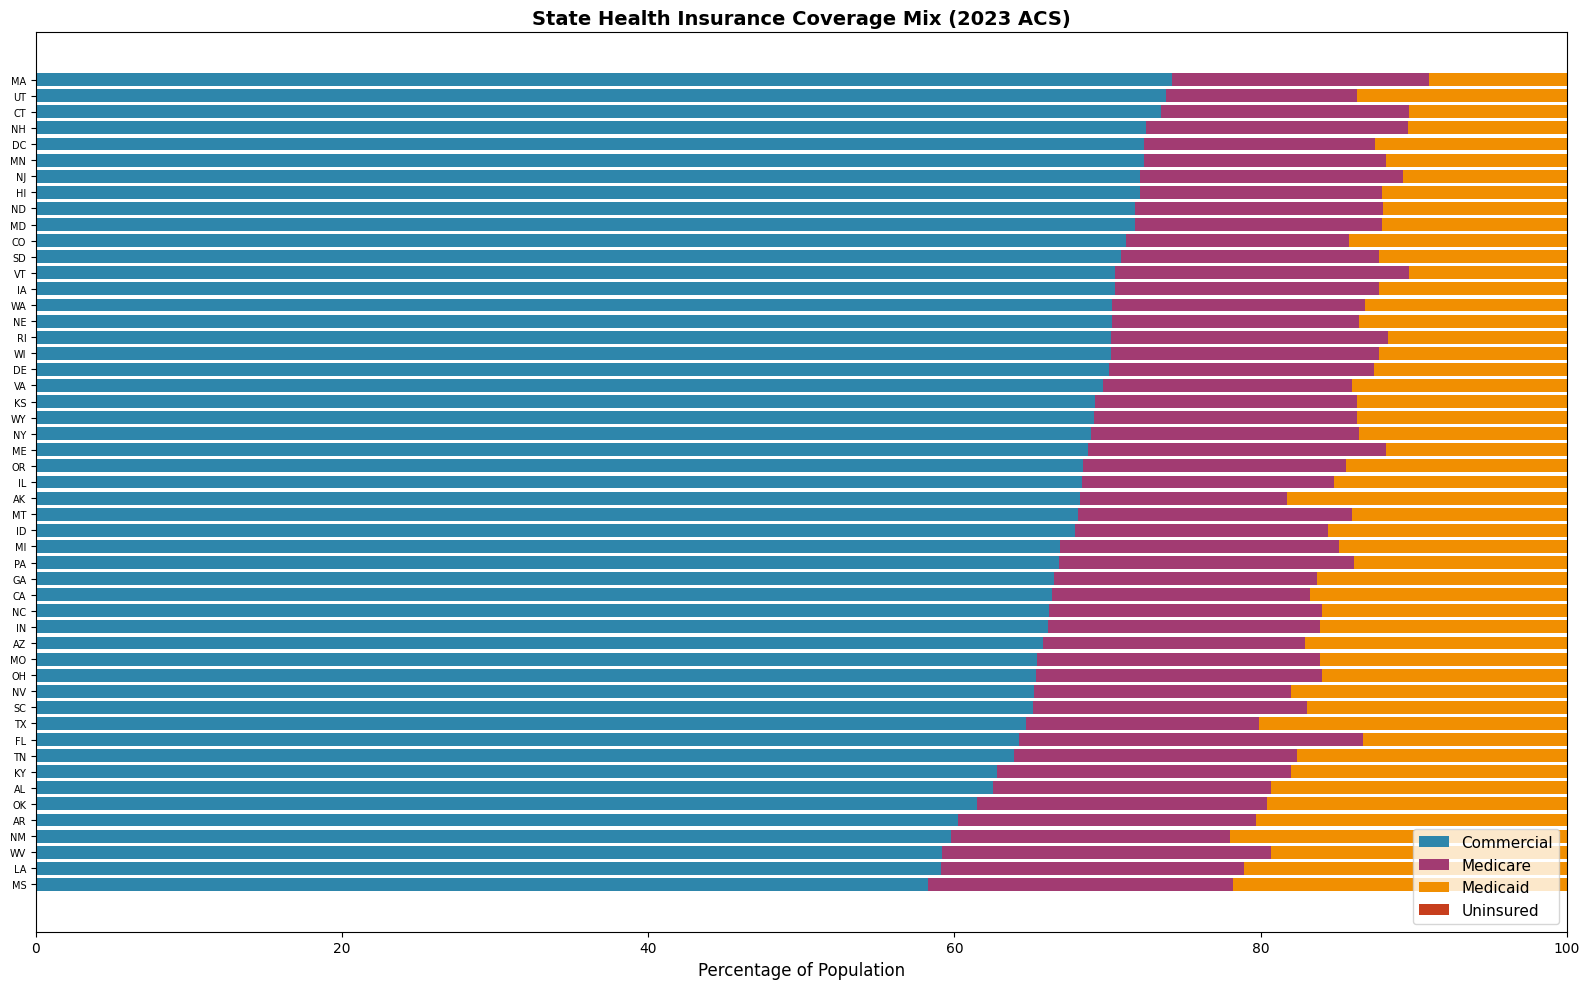

Saved: payer_mix_by_state.png


In [9]:
import matplotlib.pyplot as plt

# Stacked bar chart: payer mix by state
fig, ax = plt.subplots(figsize=(16, 10))

df_plot = df_payer_mix.sort_values('pct_commercial', ascending=True)

ax.barh(df_plot['state_abbrev'], df_plot['pct_commercial'], label='Commercial', color='#2E86AB')
ax.barh(df_plot['state_abbrev'], df_plot['pct_medicare'], left=df_plot['pct_commercial'], label='Medicare', color='#A23B72')
ax.barh(df_plot['state_abbrev'], df_plot['pct_medicaid'], left=df_plot['pct_commercial'] + df_plot['pct_medicare'], label='Medicaid', color='#F18F01')
ax.barh(df_plot['state_abbrev'], df_plot['pct_uninsured'], left=df_plot['pct_commercial'] + df_plot['pct_medicare'] + df_plot['pct_medicaid'], label='Uninsured', color='#C73E1D')

ax.set_xlabel('Percentage of Population', fontsize=12)
ax.set_title('State Health Insurance Coverage Mix (2023 ACS)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=7)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'payer_mix_by_state.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: payer_mix_by_state.png")

## 8. Visualization: Octave Covered Lives by State

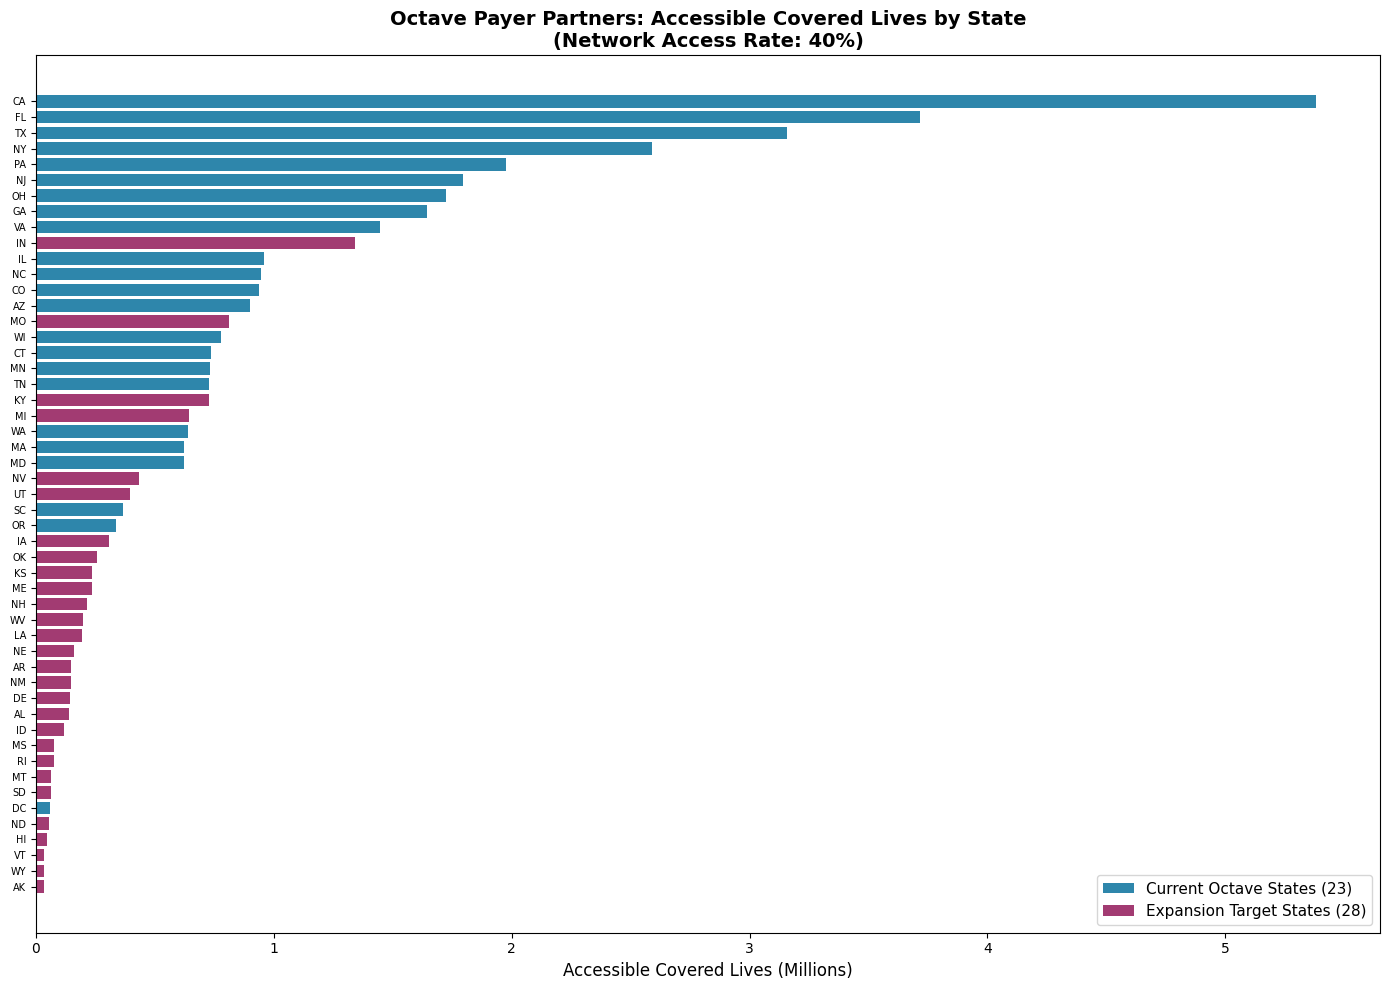

Saved: octave_covered_lives_by_state.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 10))

df_plot = df_octave_covered.sort_values('octave_accessible_covered_lives', ascending=True)
colors = ['#2E86AB' if x else '#A23B72' for x in df_plot['is_octave_state']]

ax.barh(df_plot['state_abbrev'], df_plot['octave_accessible_covered_lives'] / 1e6, color=colors)
ax.set_xlabel('Accessible Covered Lives (Millions)', fontsize=12)
ax.set_title(f'Octave Payer Partners: Accessible Covered Lives by State\n(Network Access Rate: {NETWORK_ACCESS_RATE:.0%})', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', label=f'Current Octave States ({df_octave_covered[df_octave_covered["is_octave_state"]].shape[0]})'),
    Patch(facecolor='#A23B72', label=f'Expansion Target States ({df_octave_covered[~df_octave_covered["is_octave_state"]].shape[0]})')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'octave_covered_lives_by_state.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: octave_covered_lives_by_state.png")


## 9. Top Expansion Opportunities

In [11]:
# --- Rank expansion states by accessible covered lives opportunity ---

expansion_ranked = df_octave_covered[~df_octave_covered['is_octave_state']].sort_values(
    'octave_accessible_covered_lives', ascending=False
)

print("\nTop 15 Expansion Opportunities by Accessible Covered Lives")
print(f"(Network Access Rate: {NETWORK_ACCESS_RATE:.0%})")
print("=" * 90)
print(f"{'State':<20} {'Accessible Lives':>18} {'Raw Payer Lives':>18} {'% of Expansion':>16} {'Commercial Pop':>18}")
print("-" * 90)

total_expansion = expansion_ranked['octave_accessible_covered_lives'].sum()

for idx, row in expansion_ranked.head(15).iterrows():
    pct_of_expansion = row['octave_accessible_covered_lives'] / total_expansion * 100
    print(f"{row['state_abbrev']:<20} {row['octave_accessible_covered_lives']:>18,} {row['octave_raw_payer_lives']:>18,} {pct_of_expansion:>15.1f}% {row['commercial_population']:>18,}")



Top 15 Expansion Opportunities by Accessible Covered Lives
(Network Access Rate: 40%)
State                  Accessible Lives    Raw Payer Lives   % of Expansion     Commercial Pop
------------------------------------------------------------------------------------------
IN                            1,342,630          3,356,575            18.3%          4,535,913
MO                              810,457          2,026,143            11.1%          4,052,286
KY                              727,660          1,819,151             9.9%          2,842,424
MI                              644,632          1,611,582             8.8%          6,714,927
NV                              433,181          1,082,953             5.9%          2,082,602
UT                              393,476            983,691             5.4%          2,522,287
IA                              307,487            768,718             4.2%          2,260,937
OK                              257,106            642,766    

## 10. Save Outputs

In [12]:
# --- Save payer mix table ---
output_path_mix = os.path.join(OUTPUT_DIR, 'state_payer_mix.csv')
df_payer_mix.to_csv(output_path_mix, index=False)
print(f"Saved: {output_path_mix}")
print(f"Shape: {df_payer_mix.shape}")

# --- Save covered lives table (includes both raw and accessible columns) ---
output_path_covered = os.path.join(OUTPUT_DIR, 'state_octave_covered_lives.csv')
df_octave_covered.to_csv(output_path_covered, index=False)
print(f"\nSaved: {output_path_covered}")
print(f"Shape: {df_octave_covered.shape}")
print(f"\nKey column groups in covered lives table:")
print(f"  *_raw_payer_lives       — all members of the payer brand (theoretical ceiling)")
print(f"  *_accessible_lives      — adjusted at {NETWORK_ACCESS_RATE:.0%} network access rate")
print(f"  network_access_rate     — the rate applied (constant for transparency)")
print(f"  raw_penetration_pct     — raw payer lives as % of total state population")
print(f"  accessible_penetration_pct — accessible lives as % of total state population")

# --- Save payer presence / market share table ---
output_path_payer = os.path.join(OUTPUT_DIR, 'state_octave_payer_presence.csv')
df_payer_presence.to_csv(output_path_payer, index=False)
print(f"\nSaved: {output_path_payer}")
print(f"Shape: {df_payer_presence.shape}")
print(f"\nBCBS gap: {(~df_octave_covered['has_bcbs_partner']).sum()} states without an Octave BCBS partner")
print(f"These are the primary payer development targets for expansion.")


Saved: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb03_payer_mix/state_payer_mix.csv
Shape: (51, 13)

Saved: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb03_payer_mix/state_octave_covered_lives.csv
Shape: (51, 24)

Key column groups in covered lives table:
  *_raw_payer_lives       — all members of the payer brand (theoretical ceiling)
  *_accessible_lives      — adjusted at 40% network access rate
  network_access_rate     — the rate applied (constant for transparency)
  raw_penetration_pct     — raw payer lives as % of total state population
  accessible_penetration_pct — accessible lives as % of total state population

Saved: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/proje

---

## Next: NB04 — Mental Health Demand Indicators

NB04 will use SAMHSA NSDUH data and Mental Health America rankings to quantify mental health need and treatment gaps by state, combined with provider supply from NB02.